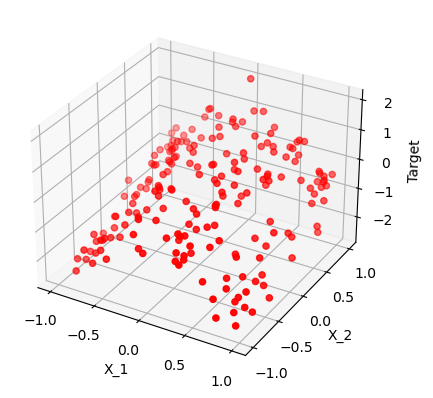

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('dataset3_1.csv', header=None)

X = df[[0, 1]].values
y = df[2].values 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, c='red', marker='o')

ax.set_xlabel('X_1')
ax.set_ylabel('X_2')
ax.set_zlabel('Target')

plt.show()


In [4]:
C_values = [1, 10, 1000]


poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)

for C in C_values:
    alpha = 1 / (2 * C) 
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    
    lasso_model.fit(X_poly, y)
    
    coefs = lasso_model.coef_
    
    feature_names = poly.get_feature_names_out(['x1', 'x2'])  # Feature names for the polynomial terms
    
    print(f"Model for C={C}:")
    for feature, coef in zip(feature_names, coefs):
        print(f"{feature},: {coef}")

Model for C=1:
1,: 0.0
x1,: 0.0
x2,: 0.0
x1^2,: -0.0
x1 x2,: 0.0
x2^2,: 0.0
x1^3,: -0.0
x1^2 x2,: 0.0
x1 x2^2,: -0.0
x2^3,: 0.0
x1^4,: -0.0
x1^3 x2,: 0.0
x1^2 x2^2,: -0.0
x1 x2^3,: 0.0
x2^4,: 0.0
x1^5,: -0.0
x1^4 x2,: 0.0
x1^3 x2^2,: -0.0
x1^2 x2^3,: 0.0
x1 x2^4,: -0.0
x2^5,: 0.0
Model for C=10:
1,: 0.0
x1,: 0.0
x2,: 0.8493203514770375
x1^2,: -1.4612305047530285
x1 x2,: 0.0
x2^2,: 0.0
x1^3,: 0.0
x1^2 x2,: 0.0
x1 x2^2,: 0.0
x2^3,: 0.0
x1^4,: -0.0
x1^3 x2,: -0.0
x1^2 x2^2,: -0.0
x1 x2^3,: 0.0
x2^4,: 0.0
x1^5,: -0.0
x1^4 x2,: 0.0
x1^3 x2^2,: -0.0
x1^2 x2^3,: 0.0
x1 x2^4,: -0.0
x2^5,: 0.0
Model for C=1000:
1,: 0.0
x1,: 0.040182104452646104
x2,: 0.8906599185448412
x1^2,: -2.099847832142753
x1 x2,: -0.0
x2^2,: 0.0
x1^3,: 0.0
x1^2 x2,: 0.0
x1 x2^2,: -0.0
x2^3,: -0.0
x1^4,: 0.0902988470119717
x1^3 x2,: -0.026113820547932605
x1^2 x2^2,: -0.0
x1 x2^3,: 0.02054777631720162
x2^4,: 0.04744551839196259
x1^5,: -0.0
x1^4 x2,: 0.22830864957327615
x1^3 x2^2,: -0.0
x1^2 x2^3,: -0.31876334744166096
x1 x2^

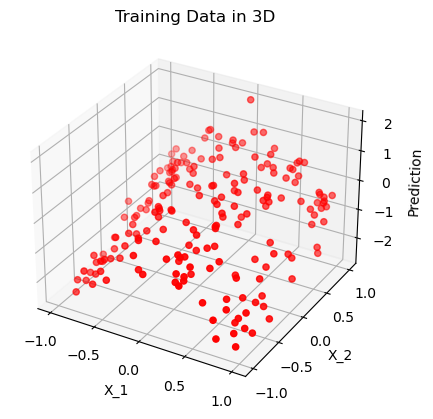

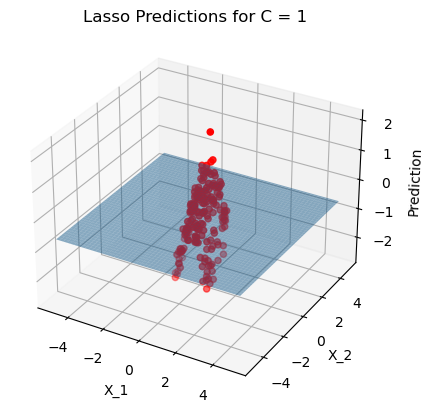

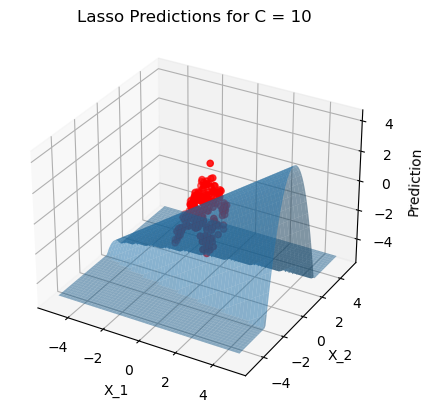

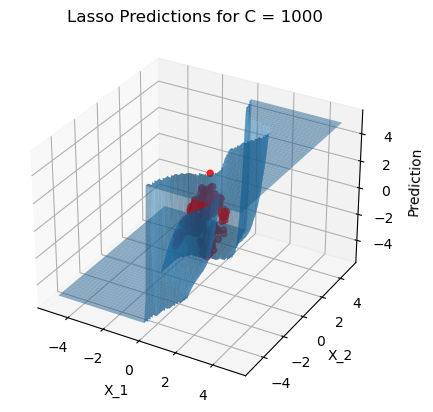

In [6]:
grid = np.linspace(-5, 5,100)
Xtest = np.array([[i, j] for i in grid for j in grid])

Xtest_poly = poly.transform(Xtest)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, color='red', label='Training Data')

ax.set_xlabel('X_1')
ax.set_ylabel('X_2')
ax.set_zlabel('Prediction')
plt.title('Training Data in 3D')
plt.show()

C_values = [1, 10, 1000]

for C in C_values:
    alpha = 1 / (2 * C)
    
    lasso_model = Lasso(alpha=alpha, max_iter=20000, tol=0.001)
    
    lasso_model.fit(X_poly, y)
    
    y_pred = lasso_model.predict(Xtest_poly)
    
    y_pred = y_pred.reshape((100, 100))
    
    y_pred_clipped = np.clip(y_pred, a_min=-5, a_max=5)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='red', label='Training Data')
    ax.plot_surface(np.meshgrid(grid, grid)[0], np.meshgrid(grid, grid)[1], y_pred_clipped, alpha=0.5)
    
    ax.set_xlabel('X_1')
    ax.set_ylabel('X_2')
    ax.set_zlabel('Prediction')
    plt.title(f'Lasso Predictions for C = {C}')
    plt.show()

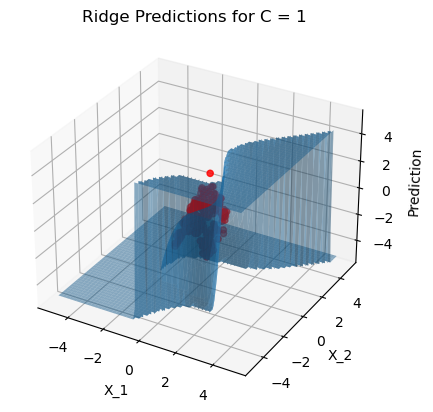

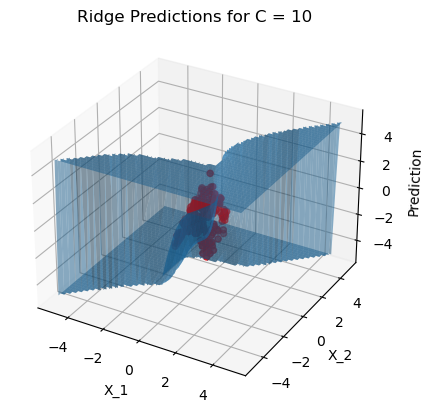

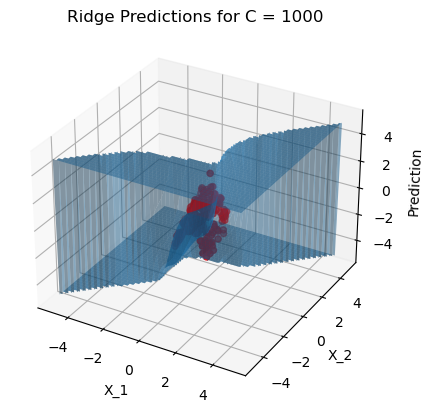

In [10]:
grid = np.linspace(-5, 5,100)
Xtest = np.array([[i, j] for i in grid for j in grid])

Xtest_poly = poly.transform(Xtest)

C_values = [1, 10, 1000]

for C in C_values:
    alpha = 1 / (2 * C)
    
    ridge_model = Ridge(alpha=alpha, max_iter=20000, tol=0.001)
    
    ridge_model.fit(X_poly, y)
    
    y_pred = ridge_model.predict(Xtest_poly)
    
    y_pred = y_pred.reshape((100, 100))
    
    y_pred_clipped = np.clip(y_pred, a_min=-5, a_max=5) 
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='red', label='Training Data')
    ax.plot_surface(np.meshgrid(grid, grid)[0], np.meshgrid(grid, grid)[1], y_pred_clipped, alpha=0.5)
    
    ax.set_xlabel('X_1')
    ax.set_ylabel('X_2')
    ax.set_zlabel('Prediction')
    plt.title(f'Ridge Predictions for C = {C}')
    plt.show()

In [13]:
for C in C_values:
    alpha = 1 / (2 * C)
    
    ridge_model = Ridge(alpha=alpha, max_iter=20000, tol=0.001)
    ridge_model.fit(X_poly, y)

    coefs = ridge_model.coef_
    
    feature_names = poly.get_feature_names_out(['x1', 'x2'])
    
    print(f"Ridge for C={C}:")
    for feature, coef in zip(feature_names, coefs):
        print(f"{feature}: {coef}")
    print("\n")

Ridge for C=1:
1: 0.0
x1: 0.046939803728794575
x2: 0.843254677695572
x1^2: -1.6447572299480977
x1 x2: -0.01140793625285304
x2^2: 0.041691984412710874
x1^3: 0.08782487383119471
x1^2 x2: 0.02290824363197302
x1 x2^2: -0.01832661902267905
x2^3: 0.07734977455975024
x1^4: -0.30022192544724785
x1^3 x2: -0.02038175114149919
x1^2 x2^2: -0.21794567018922878
x1 x2^3: 0.042449801357195394
x2^4: 0.07683160321633269
x1^5: -0.10702359313592587
x1^4 x2: 0.22286272753714562
x1^3 x2^2: 0.07886321540357435
x1^2 x2^3: -0.2863783349183977
x1 x2^4: -0.09421302257263092
x2^5: 0.20988567228721017


Ridge for C=10:
1: 0.0
x1: -0.031681289306698994
x2: 0.9405966823948853
x1^2: -2.1502613799514214
x1 x2: -0.02775156827665331
x2^2: 0.0656844227591196
x1^3: 0.4357175347232298
x1^2 x2: -0.016737795394374796
x1 x2^2: -0.06319565677547138
x2^3: -0.2724734363209529
x1^4: 0.16934442799363303
x1^3 x2: -0.09677271369008973
x1^2 x2^2: -0.03358731530779903
x1 x2^3: 0.1295820039238629
x2^4: -0.004423076208629541
x1^5: -0.40

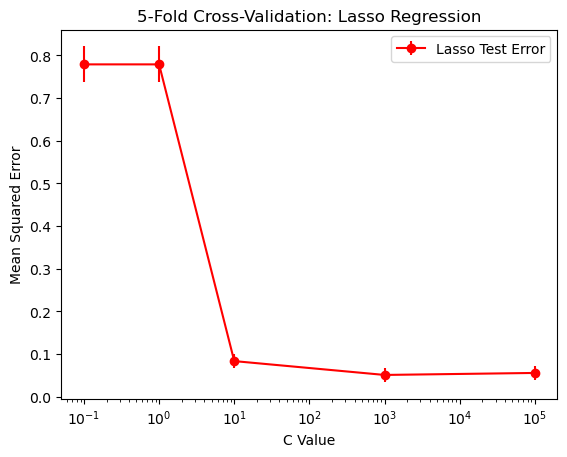

In [17]:
C_range = [0.1, 1, 10, 1000,100000]

mean_error_lasso = []
std_error_lasso = []

kf = KFold(n_splits=5)

def cross_val_model_lasso(model, X_poly, y):
    temp_train_errors = []
    temp_test_errors = []
    
    for train_idx, test_idx in kf.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        temp_train_errors.append(train_mse)
        temp_test_errors.append(test_mse)
    
    return np.mean(temp_train_errors), np.std(temp_train_errors), np.mean(temp_test_errors), np.std(temp_test_errors)

for C in C_range:
    alpha = 1 / (2 * C)
    
    # Lasso model
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    mean_train, std_train, mean_test, std_test = cross_val_model_lasso(lasso_model, X_poly, y)
    
    mean_error_lasso.append(mean_test)
    std_error_lasso.append(std_test)

plt.errorbar(C_range, mean_error_lasso, yerr=std_error_lasso, label='Lasso Test Error', fmt='-o', color='red')
plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Mean Squared Error')
plt.title('5-Fold Cross-Validation: Lasso Regression')
plt.legend()
plt.show()

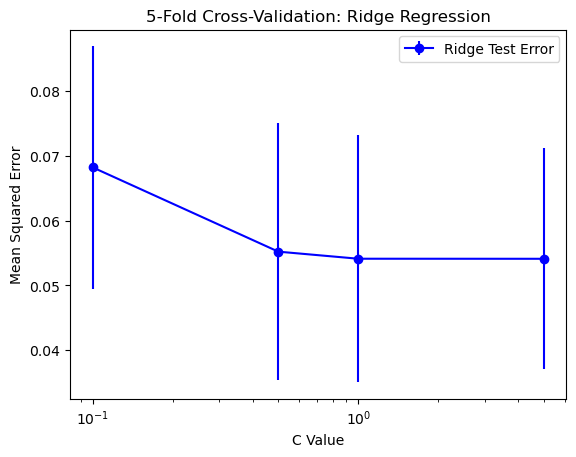

In [13]:
C_range = [0.1, 1, 10, 1000,100000]

mean_error_ridge = []
std_error_ridge = []

kf = KFold(n_splits=5)

def cross_val_model_ridge(model, X_poly, y):
    temp_train_errors = []
    temp_test_errors = []
    
    for train_idx, test_idx in kf.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        temp_train_errors.append(train_mse)
        temp_test_errors.append(test_mse)
    
    return np.mean(temp_train_errors), np.std(temp_train_errors), np.mean(temp_test_errors), np.std(temp_test_errors)

for C in C_range:
    alpha = 1 / (2 * C)  
    
    ridge_model = Ridge(alpha=alpha, max_iter=10000)
    mean_train, std_train, mean_test, std_test = cross_val_model_ridge(ridge_model, X_poly, y)
    
    mean_error_ridge.append(mean_test)
    std_error_ridge.append(std_test)

plt.errorbar(C_range, mean_error_ridge, yerr=std_error_ridge, label='Ridge Test Error', fmt='-o', color='blue')
plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Mean Squared Error')
plt.title('5-Fold Cross-Validation: Ridge Regression')
plt.legend()
plt.show()